In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

df = pd.read_csv(r'C:\Users\Usuario\OneDrive\Documents\Gimnasios Model Fitness\gym_churn_us.csv')
df.head()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0


In [2]:
#EXPLORACIÓN INICIAL (EDA)
df.info()
df.describe()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          4000 non-null   float

gender                               0
Near_Location                        0
Partner                              0
Promo_friends                        0
Phone                                0
Contract_period                      0
Group_visits                         0
Age                                  0
Avg_additional_charges_total         0
Month_to_end_contract                0
Lifetime                             0
Avg_class_frequency_total            0
Avg_class_frequency_current_month    0
Churn                                0
dtype: int64

In [3]:
#COMPARAR CHURN VS NO CHURN
df.groupby('Churn').mean()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month
Churn,,,,,,,,,,,,,
0,0.510037,0.873086,0.534195,0.353522,0.903709,5.747193,0.464103,29.976523,158.445715,5.283089,4.711807,2.024876,2.027882
1,0.510839,0.768143,0.355325,0.183789,0.902922,1.728558,0.268615,26.989632,115.082899,1.662582,0.990575,1.474995,1.044546


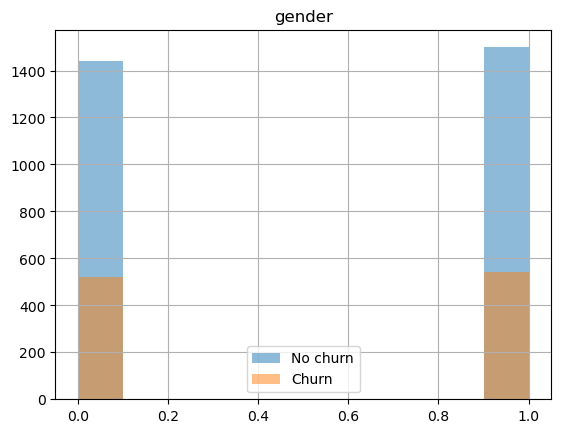

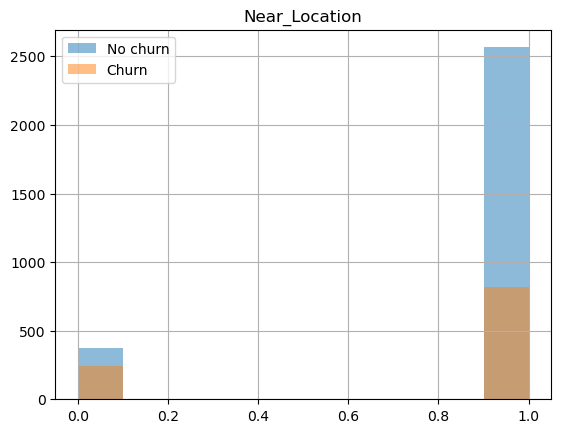

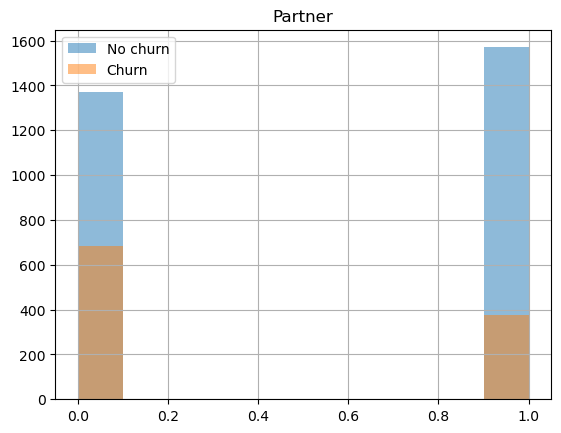

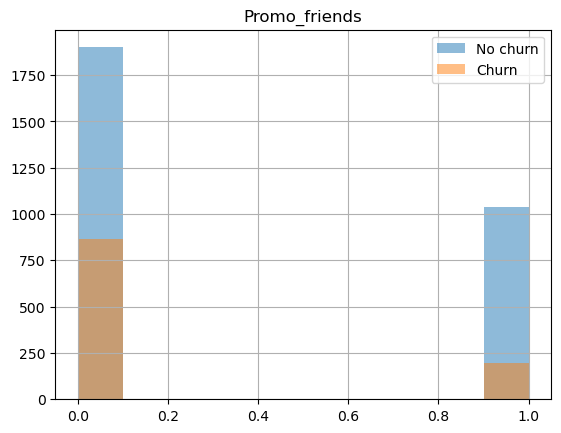

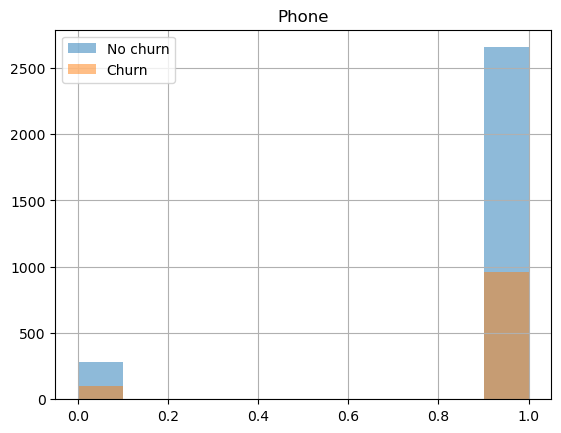

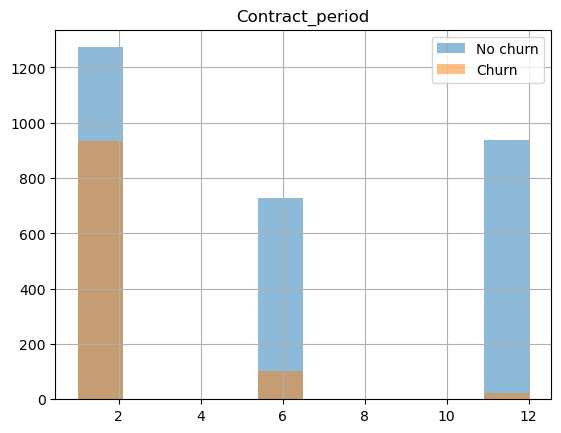

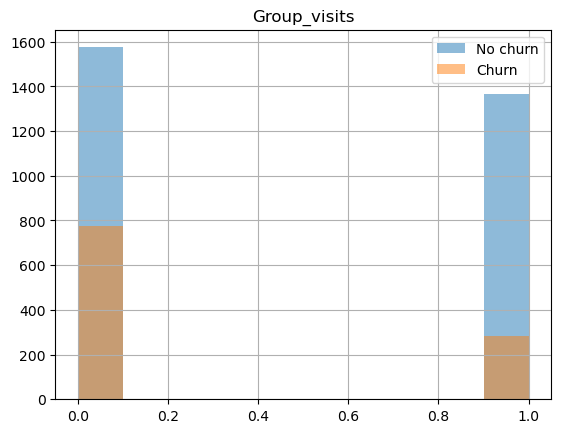

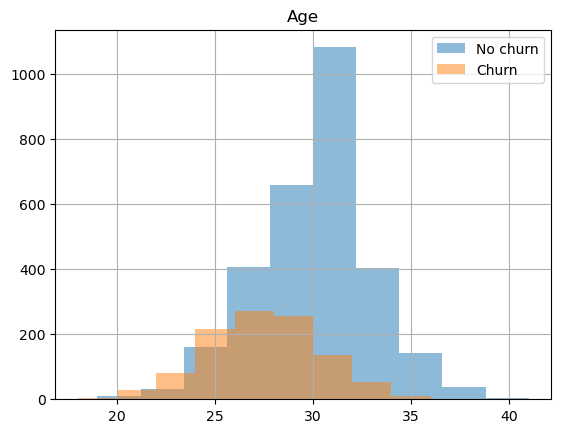

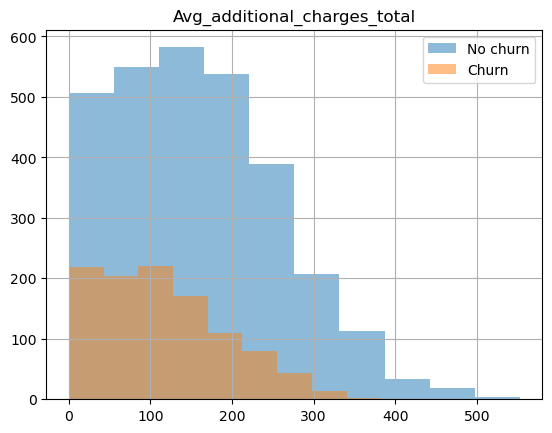

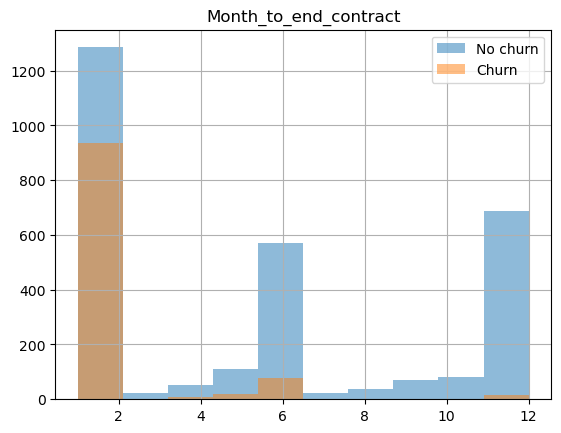

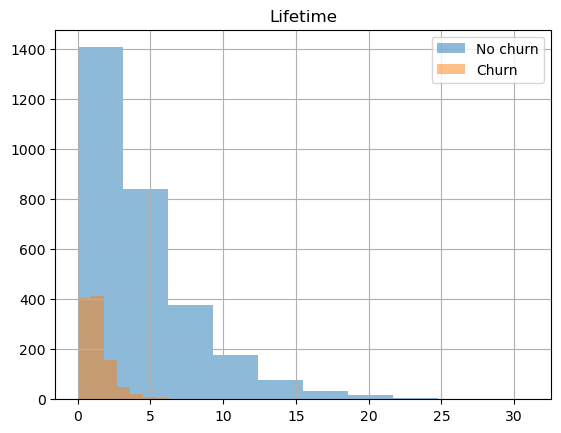

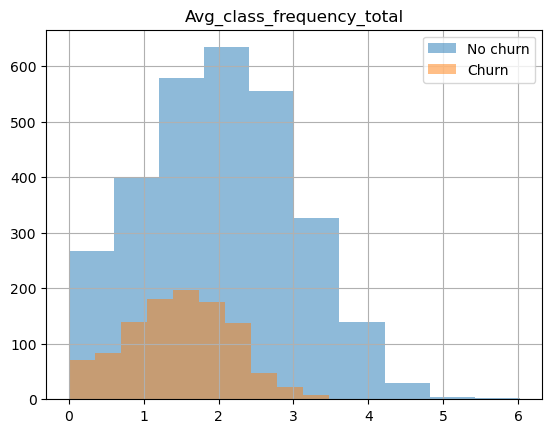

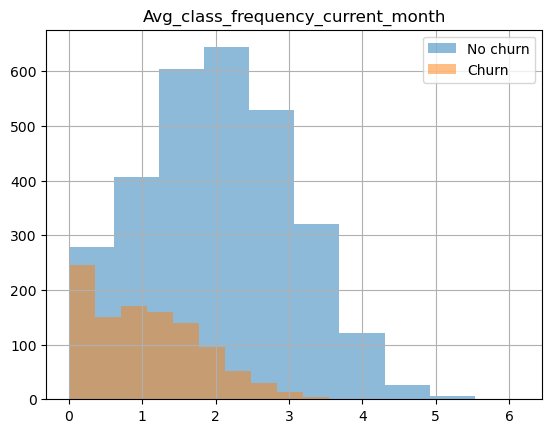

In [4]:
#visualizar Churn VS no Churn

for col in df.columns:
    if col != 'Churn':
        df[df['Churn']==0][col].hist(alpha=0.5, label='No churn')
        df[df['Churn']==1][col].hist(alpha=0.5, label='Churn')
        plt.legend()
        plt.title(col)
        plt.show()

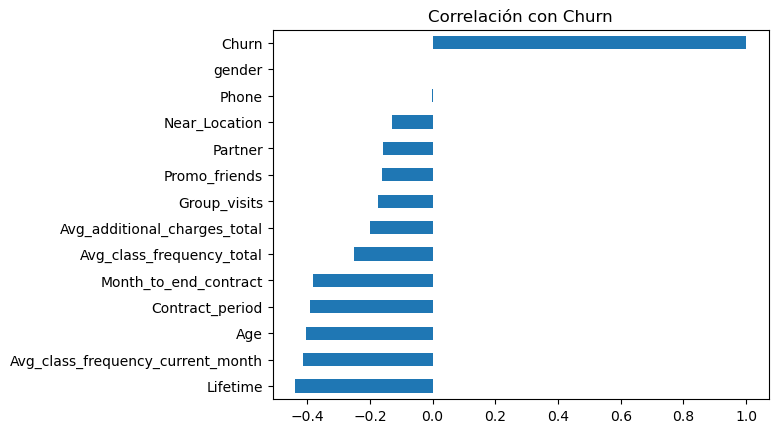

In [5]:
#Correlacion

corr = df.corr()['Churn'].sort_values()

corr.plot(kind='barh')
plt.title('Correlación con Churn')
plt.show()

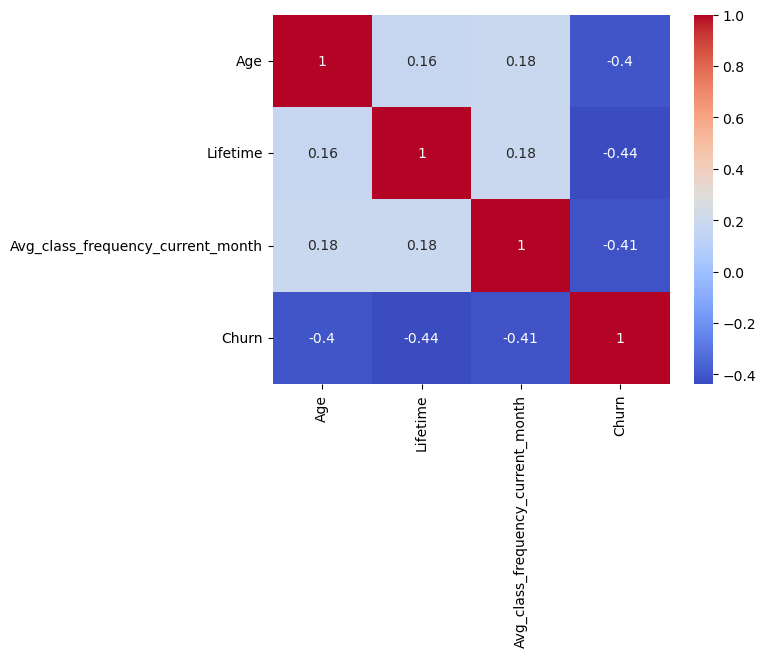

In [6]:
#variables importantes
important_cols = ['Age', 'Lifetime', 'Avg_class_frequency_current_month', 'Churn']

sns.heatmap(df[important_cols].corr(), annot=True, cmap='coolwarm')
plt.show()

Se analizó la correlación de las variables con la cancelación (Churn), identificando qué factores tienen mayor impacto en la pérdida de clientes.

In [7]:
#modelo de prediccion DEFINIR VARIABLES

X = df.drop('Churn', axis=1)
y = df['Churn']

In [8]:
#Dividir datos

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
#Regresion logistica

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))

Accuracy: 0.91625
Precision: 0.8729281767955801
Recall: 0.7821782178217822


In [10]:
#Random forest

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))

Accuracy: 0.91
Precision: 0.8494623655913979
Recall: 0.7821782178217822


Se entrenaron dos modelos de clasificación (regresión logística y Random Forest) para predecir la cancelación de clientes. Se evaluaron utilizando métricas como accuracy, precision y recall.

El modelo Random Forest mostró mejor desempeño en la predicción de churn, especialmente en recall, lo que lo hace más útil para identificar clientes en riesgo.

In [11]:
#CLUSTERING (segmentación de clientes)

X_cluster = df.drop('Churn', axis=1)

In [12]:
#Escalar datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

In [13]:
# K means

kmeans = KMeans(n_clusters=5, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

In [14]:
#ANALIZAR CLUSTERS
df.groupby('cluster').mean()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
cluster,,,,,,,,,,,,,,
0,0.484801,0.698363,0.301637,0.007015,0.899454,1.733437,0.255651,28.074825,127.131782,1.657833,2.089634,1.256531,0.991781,0.587685
1,0.494471,0.947867,0.791469,0.998420,0.906793,2.740916,0.431280,28.903633,139.456908,2.540284,3.529226,1.619489,1.488508,0.285940
2,0.464396,0.913313,0.766254,0.493808,0.925697,10.495356,0.506192,30.091331,164.190347,9.484520,4.693498,2.888801,2.886027,0.013932
3,0.547794,0.937500,0.742647,0.424632,0.863971,11.194853,0.575368,29.720588,167.670439,10.347426,4.818015,1.154578,1.139605,0.042279
4,0.568233,0.878076,0.178971,0.048098,0.914989,2.120805,0.456376,29.993289,155.602830,2.013423,4.844519,2.667290,2.650122,0.105145


In [15]:
#TASA DE CANCELACION DE GRUPO
df.groupby('cluster')['Churn'].mean()

cluster
0    0.587685
1    0.285940
2    0.013932
3    0.042279
4    0.105145
Name: Churn, dtype: float64

Se identificaron 5 clusters de clientes con diferentes comportamientos.

El cluster 0 presenta la mayor tasa de cancelación (58.7%), lo que indica un grupo de alto riesgo. Por otro lado, los clusters 2 y 3 muestran tasas muy bajas de churn (1.3% y 4.2%), representando clientes leales.

Estos resultados permiten identificar segmentos clave para estrategias de retención, enfocando esfuerzos en los grupos con mayor probabilidad de abandono.

- Enfocar estrategias de retención en el cluster 0, como promociones o seguimiento personalizado
- Analizar características de los clusters leales para replicar ese comportamiento
- Incentivar contratos más largos en clientes de riesgo
- Promover mayor frecuencia de visitas mediante programas de engagement

Lo que encontre:
  Identifiqué segmentos de clientes con diferentes niveles de riesgo de cancelación. 
Por ejemplo, un grupo presenta más del 50% de churn, lo que permite enfocar estrategias específicas de retención.